In [1]:
from pathlib import Path
import json, sys
import pandas as pd
import matplotlib.pyplot as plt
sys.dont_write_bytecode = True
ROOT = next((candidate for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (candidate / 'scripts/phase4_feature_engineering.py').is_file()), None)
assert ROOT is not None, 'Open this notebook from within the magic_Lotto repository.'
sys.path.insert(0, str(ROOT))
from scripts.phase4_feature_engineering import build_core
payloads, validation = build_core(ROOT)
for relative, content in payloads.items():
    assert (ROOT / relative).read_bytes() == content, f'Saved artifact differs: {relative}'
features3 = pd.read_csv(ROOT / 'data/features/3d_features.csv')
targets3 = pd.read_csv(ROOT / 'data/features/3d_targets.csv')
features6 = pd.read_csv(ROOT / 'data/features/642_features.csv')
targets6 = pd.read_csv(ROOT / 'data/features/642_targets.csv')
dictionary = json.loads((ROOT / 'data/features/feature_dictionary.json').read_text(encoding='utf-8'))
split_manifest = json.loads((ROOT / 'data/features/chronological_splits.json').read_text(encoding='utf-8'))
validation = json.loads((ROOT / 'reports/phase4_validation.json').read_text(encoding='utf-8'))
print('Saved core artifacts match a fresh deterministic build.')

Saved core artifacts match a fresh deterministic build.


## 1. Phase 4 Objective and Scope

Question: What does Phase 4 deliver? Method: construct historical features, unordered targets, fixed chronological splits, and audits only. Interpretation: these are inputs for a later backtest, not predictions. Limitation: no model is trained and no test performance is measured.

## 2. Canonical Inputs and Provenance

Question: Which canonical data and prior-phase evidence are used? Method: verify Phase 1 through Phase 3 artifacts and compare source hashes. Interpretation: each row is keyed by draw_date and source_row. Limitation: hashes establish byte identity, not upstream correctness beyond the recorded validation.

In [2]:
print('Repository:', ROOT)
print('Source input hashes:')
for name, digest in sorted(validation['canonical_input_hashes'].items()):
    print(name, digest)
print('Phase 3 verdict:', validation['preflight']['phase3_verdict'])

Repository: D:\Dev\Repositories\magic_Lotto
Source input hashes:
lotto_6_42_cleaned_normalized.csv 980386a399077564d25de3a3a19aa3611969899895b9e3c06d7e9406599053a0
lotto_6_42_number_frequency.csv 1284586aaccc86f43da2e9676f425842dbf171dde36d8d8da2b4027789252456
lotto_6_42_phase2_analysis.csv a7ff6ac667ab9a4dd83c821ca6a7ad94b2866ab15299f5f0ad7e47818ac32958
phase2_randomness_diagnostics.md c6318f74cc5685108f4bb278d6293b84771e0c29af7250888a789aec365cbce7
swertres_9pm_analysis_ready.csv bed32547054a819e108f18d53af73db1f74db693202db066c64572846860959b
swertres_9pm_cleaned_normalized.csv 3118bc4972bbff55db6029342701c870ca3e4735e26ddcdf6bbe86ee018836cc
swertres_9pm_digit_frequency.csv 4ad90a87cbaaca99a08001904b7bbef18e1561ed4b9c5a138f0253729b359681
swertres_9pm_phase2_analysis.csv 3b207b356349c0bf4e1677979c1077bea434071508e3f835e4fc75e9997d7d72
Phase 3 verdict: PHASE3_PASS_RANDOM_COMPATIBLE


## 3. Temporal Leakage Rule

Question: Can row t see its own or later draw? Method: every feature uses indices less than t, followed by sampled future-perturbation checks. Interpretation: target t is excluded from rolling, expanding, lag, gap, and overlap calculations. Limitation: the audit samples representative indices and also checks the shared construction rules.

In [3]:
print(pd.DataFrame([{'game': game, 'status': item['status'], 'checks': len(item['checks']), 'sampled target indices': item['sampled_target_indices']} for game, item in validation['leakage_audit'].items()]))

         game status  checks  sampled target indices
0    3d_lotto   PASS       7  [101, 102, 1859, 3717]
1  lotto_6_42   PASS       7   [101, 102, 802, 1604]


## 4. Target Representation: 3D Lotto

Question: How are repeated digits retained? Method: encode each draw as ten digit counts from an unordered multiset. Interpretation: each row contains values 0 through 3 summing to 3. Limitation: the output intentionally discards published digit position.

In [4]:
target_checks = []
for game, name, total in [('3d_lotto', '3d_targets.csv', 3), ('lotto_6_42', '642_targets.csv', 6)]:
    frame = pd.read_csv(ROOT / 'data/features' / name)
    values = frame.iloc[:, 2:].to_numpy()
    target_checks.append({'game': game, 'rows': len(frame), 'target_columns': values.shape[1], 'min': int(values.min()), 'max': int(values.max()), 'row_sum_min': int(values.sum(axis=1).min()), 'row_sum_max': int(values.sum(axis=1).max()), 'required_row_sum': total})
print(pd.DataFrame(target_checks))

         game  rows  target_columns  min  max  row_sum_min  row_sum_max  \
0    3d_lotto  3617              10    0    3            3            3   
1  lotto_6_42  1504              42    0    1            6            6   

   required_row_sum  
0                 3  
1                 6  


## 5. Target Representation: Lotto 6/42

Question: How is each draw represented? Method: parse the canonical sorted combination into a set and emit binary membership for 1 through 42. Interpretation: each row has six positive labels. Limitation: published draw order is not retained in the target matrix.

In [5]:
target_checks = []
for game, name, total in [('3d_lotto', '3d_targets.csv', 3), ('lotto_6_42', '642_targets.csv', 6)]:
    frame = pd.read_csv(ROOT / 'data/features' / name)
    values = frame.iloc[:, 2:].to_numpy()
    target_checks.append({'game': game, 'rows': len(frame), 'target_columns': values.shape[1], 'min': int(values.min()), 'max': int(values.max()), 'row_sum_min': int(values.sum(axis=1).min()), 'row_sum_max': int(values.sum(axis=1).max()), 'required_row_sum': total})
print(pd.DataFrame(target_checks))

         game  rows  target_columns  min  max  row_sum_min  row_sum_max  \
0    3d_lotto  3617              10    0    3            3            3   
1  lotto_6_42  1504              42    0    1            6            6   

   required_row_sum  
0                 3  
1                 6  


## 6. Historical Feature Definitions

Question: What features are available to the later backtest? Method: use the machine-readable feature dictionary and the fixed 10, 30, and 100 draw windows. Interpretation: feature names identify entity, metric, and history window. Limitation: no extra windows or data sources are introduced.

In [6]:
print(pd.DataFrame([{'game': game, 'feature_count': spec['feature_count'], 'feature_groups': len(spec['features'])} for game, spec in dictionary.items() if isinstance(spec, dict) and 'features' in spec]))

         game  feature_count  feature_groups
0    3d_lotto            107             107
1  lotto_6_42            391             391


## 7. Rolling and Expanding Feature Construction

Question: How are historical frequencies calculated? Method: count exact prior windows and cumulative prior history; digit frequencies divide by prior digit slots, Lotto frequencies by prior draws. Interpretation: deviations use fair marginal references 0.1 and 6/42. Limitation: these are descriptive rates and imply no predictive value.

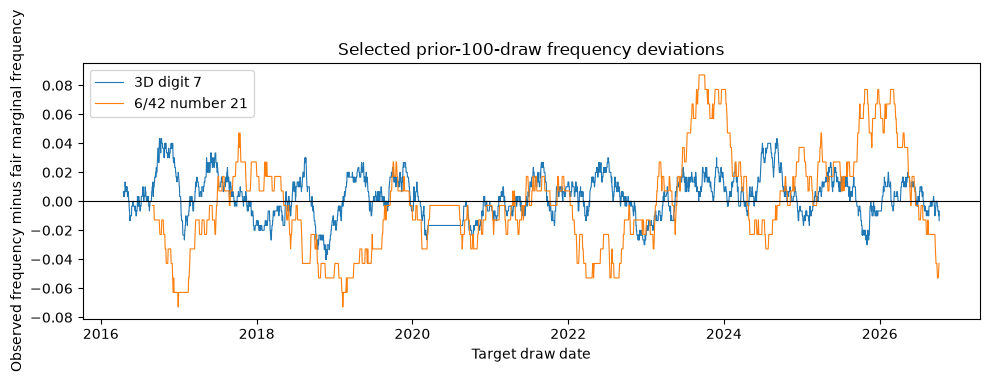

In [7]:
sample3 = features3[['draw_date', 'digit_7_freq_deviation_prev_100']].copy()
sample6 = features6[['draw_date', 'num_21_freq_deviation_prev_100']].copy()
sample3['draw_date'] = pd.to_datetime(sample3['draw_date'])
sample6['draw_date'] = pd.to_datetime(sample6['draw_date'])
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(sample3['draw_date'], sample3['digit_7_freq_deviation_prev_100'], linewidth=0.8, label='3D digit 7')
ax.plot(sample6['draw_date'], sample6['num_21_freq_deviation_prev_100'], linewidth=0.8, label='6/42 number 21')
ax.axhline(0, color='black', linewidth=0.8)
ax.legend()
ax.set(title='Selected prior-100-draw frequency deviations', xlabel='Target draw date', ylabel='Observed frequency minus fair marginal frequency')
fig.tight_layout()

## 8. Gap and Recency Features

Question: How is recency defined when an entity has never appeared? Method: count completed draws since the last prior appearance, and pair null gap with never_seen=1 when absent. Interpretation: a gap of zero means appearance in t-1. Limitation: early rows are excluded until the longest required history is available.

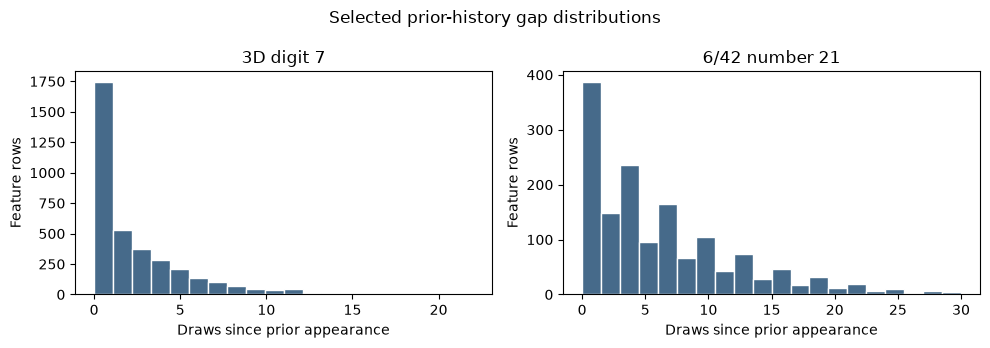

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for ax, frame, column, title in [(axes[0], features3, 'digit_7_gap_since_seen', '3D digit 7'), (axes[1], features6, 'num_21_gap_since_seen', '6/42 number 21')]:
    values = frame[column].dropna()
    ax.hist(values, bins=20, color='#466a8a', edgecolor='white')
    ax.set(title=title, xlabel='Draws since prior appearance', ylabel='Feature rows')
fig.suptitle('Selected prior-history gap distributions')
fig.tight_layout()

## 9. Draw-Level Context Features

Question: Which properties of prior draws are summarized? Method: summarize sums, population variances, patterns, odd counts, and completed transition overlaps. Interpretation: all summaries end at t-1. Limitation: they are descriptive context only.

In [9]:
context = [name for name in features3.columns if name.startswith(('previous_', 'digit_sum_', 'one_pair_', 'triple_', 'multiset_'))]
context6 = [name for name in features6.columns if name.startswith(('previous_', 'draw_sum_', 'odd_count_', 'set_overlap_'))]
print('3D context columns:', len(context))
print('6/42 context columns:', len(context6))
print('Variance convention: population variance (ddof=0). Overlap windows count completed transitions.')

3D context columns: 14
6/42 context columns: 13
Variance convention: population variance (ddof=0). Overlap windows count completed transitions.


## 10. Missing-History Treatment

Question: How are incomplete histories handled? Method: exclude the first 101 target rows to provide 100 prior draws and 100 prior transitions. Interpretation: only never-seen gap cells can remain null thereafter. Limitation: this reduces the available sample.

In [10]:
missing = []
for game, frame in [('3d_lotto', features3), ('lotto_6_42', features6)]:
    gaps = [name for name in frame.columns if name.endswith('_gap_since_seen')]
    missing.append({'game': game, 'feature_rows': len(frame), 'gap_columns': len(gaps), 'null_gap_cells': int(frame[gaps].isna().sum().sum()), 'never_seen_flags': int(frame[[n for n in frame if n.endswith('_never_seen')]].sum().sum())})
print(pd.DataFrame(missing))

         game  feature_rows  gap_columns  null_gap_cells  never_seen_flags
0    3d_lotto          3617           10               0                 0
1  lotto_6_42          1504           42               0                 0


## 11. Feature-Matrix Verification

Question: Do features and targets align by draw? Method: compare stable keys and check target invariants and missingness rules. Interpretation: row order is identical within each game. Limitation: keys establish row identity, not causal meaning.

In [11]:
alignment = []
for game, feature, target in [('3d_lotto', features3, targets3), ('lotto_6_42', features6, targets6)]:
    alignment.append({'game': game, 'same_rows': len(feature) == len(target), 'same_keys': feature[['draw_date', 'source_row']].equals(target[['draw_date', 'source_row']]), 'feature_columns': feature.shape[1]-2, 'target_columns': target.shape[1]-2})
print(pd.DataFrame(alignment))

         game  same_rows  same_keys  feature_columns  target_columns
0    3d_lotto       True       True              107              10
1  lotto_6_42       True       True              391              42


## 12. Chronological Train Validation Test Split

Question: How are partitions frozen? Method: floor 60 percent for train, floor 20 percent for validation, and assign the remainder to the newest test partition. Interpretation: boundaries are non-overlapping and persisted. Limitation: Phase 4 does not inspect test-label performance.

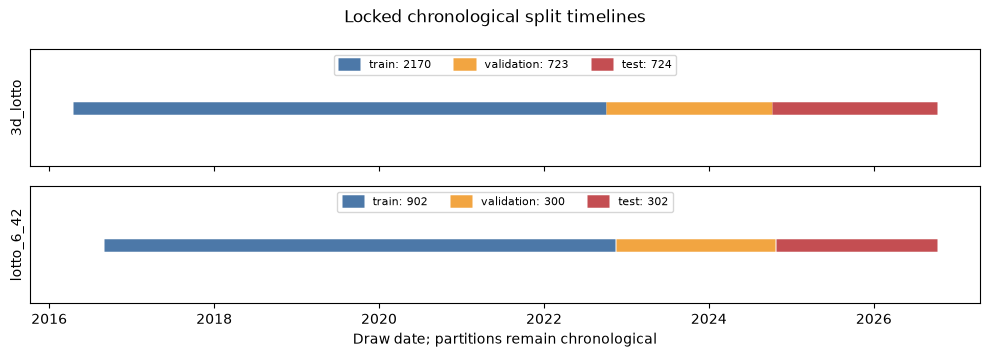

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(10, 3.6), sharex=True)
for ax, game in zip(axes, ['3d_lotto', 'lotto_6_42']):
    parts = split_manifest['games'][game]['partitions']
    for y, (name, color) in enumerate([('train', '#4c78a8'), ('validation', '#f2a541'), ('test', '#c44e52')]):
        span = parts[name]
        ax.plot([pd.Timestamp(span['start_date']), pd.Timestamp(span['end_date'])], [0, 0], linewidth=9, solid_capstyle='butt', color=color, label=f"{name}: {span['row_count']}")
    ax.set_yticks([])
    ax.set_ylabel(game)
    ax.legend(ncol=3, loc='upper center', fontsize=8)
axes[-1].set_xlabel('Draw date; partitions remain chronological')
fig.suptitle('Locked chronological split timelines')
fig.tight_layout()

## 13. Leakage Audit

Question: Have temporal and positional leakage checks passed? Method: direct prior-slice checks, lag/gap verification, permutation invariance, and future perturbation. Interpretation: all recorded checks must pass. Limitation: this validates construction, not future model design.

In [13]:
print(pd.DataFrame([{'game': game, 'status': item['status'], 'checks': len(item['checks']), 'sampled target indices': item['sampled_target_indices']} for game, item in validation['leakage_audit'].items()]))

         game status  checks  sampled target indices
0    3d_lotto   PASS       7  [101, 102, 1859, 3717]
1  lotto_6_42   PASS       7   [101, 102, 802, 1604]


## 14. Feature Distribution Diagnostics

Question: What do selected feature histories look like? Method: chart rolling frequency deviations, gap distributions, and missingness. Interpretation: charts describe feature variation only. Limitation: no chart is evidence of predictive usefulness.

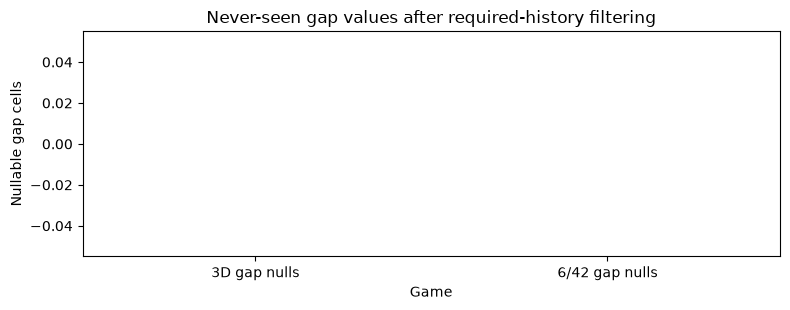

In [14]:
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.bar(['3D gap nulls', '6/42 gap nulls'], [validation['games']['3d_lotto']['gap_null_cells'], validation['games']['lotto_6_42']['gap_null_cells']], color=['#466a8a', '#8a6da8'])
ax.set(title='Never-seen gap values after required-history filtering', ylabel='Nullable gap cells', xlabel='Game')
fig.tight_layout()

## 15. Phase 4 Validation Summary

Question: Did the required engineering checks pass? Method: read the machine-readable validation summary and verify saved artifact hashes. Interpretation: only a fully passing status supports readiness. Limitation: later model evaluation remains out of scope.

In [15]:
print('Verdict:', validation['verdict'])
print('Notebook execution:', validation['notebook_execution'])
print(pd.DataFrame([{'artifact': name, 'sha256': digest} for name, digest in validation['reproducibility']['artifact_hashes'].items()]))

Verdict: PHASE4_PASS_READY_FOR_ML_BASELINE
Notebook execution: {'code_cells': 16, 'error_outputs': 0, 'executed_code_cells': 16, 'nbformat_validation': 'PASS', 'status': 'PASS'}
                                  artifact  \
0            data/features/3d_features.csv   
1             data/features/3d_targets.csv   
2           data/features/642_features.csv   
3            data/features/642_targets.csv   
4  data/features/chronological_splits.json   
5    data/features/feature_dictionary.json   

                                              sha256  
0  09ad8a7d2360eb59ad35e5fb836854f372a6291ca3d861...  
1  86de523ebdc7e80af2b7764be36be6ec26f8d95af7b686...  
2  409a524abc0fcebebf8fbbc65362ab95ba04e346d11d3c...  
3  4c0bda750e3b758808bb65a9e236c20e2cbedbf768faa3...  
4  7265ad3acf5a039ea7568f07db51877be0115cba5fd404...  
5  2c7faab68cb76fb12166a3fb40edfc3e7e1ffbecc322a2...  


## 16. Phase 5 Readiness

Question: What can Phase 5 safely consume? Method: use exact persisted keys, matrices, feature definitions, and split boundaries. Interpretation: a future baseline comparison can begin from the locked chronology. Limitation: no Phase 5 model or performance claim is created here.

In [16]:
print(pd.DataFrame([{'game': game, 'features': details['feature_count'], 'targets': details['target_count'], 'eligible_rows': details['eligible_rows'], 'excluded_early_rows': details['rows_excluded_insufficient_history']} for game, details in validation['games'].items()]))
print('Test partition locked:', split_manifest['test_partition_locked'])
print('Model training:', 'not performed')
print('Test performance:', 'not calculated')

         game  features  targets  eligible_rows  excluded_early_rows
0    3d_lotto       107       10           3617                  101
1  lotto_6_42       391       42           1504                  101
Test partition locked: True
Model training: not performed
Test performance: not calculated


## 17. Limitations

Question: What should readers avoid concluding? Method: interpret all outputs as historical feature engineering only. Interpretation: no numbers are recommended and no hot, cold, due, or lucky claim is made. Limitation: lottery outcomes remain uncertain and feature variation alone is not evidence of an edge.